# Exploratory Analysis: Policy Brief Coding Framework

This notebook summarizes the results of automated policy brief analysis, organized around the **original coding framework** rather than raw extraction mechanics.

The pipeline extracts structured information from policy brief PDFs. This notebook aggregates those fine-grained extractions into **document-level indicators** that map to the conceptual dimensions of the coding scheme.

**Sections:**
1. Data Loading & QA
2. Mapping Extracted Outputs to the Coding Framework
3. Document-Level Framework Indicators (aggregated `analysis_df`)
4. A. Structure
5. B. Content Structure
6. C. Bridging Role (Recommendations)
7. D. Facilitating Role (Policy Options)
8. E. Accessibility
9. F. Narrative & Framing
10. G. Transparency
11. H. Theory-Informed Policy-Instrument Frames
12. QA Appendix: Raw Extraction Distributions

In [25]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore', category=FutureWarning)

In [26]:
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

OUTPUT_DIR = Path.cwd() / 'output'

# ── Load CSVs robustly ──────────────────────────────────────────────────
def _load(name):
    p = OUTPUT_DIR / name
    if not p.exists():
        print(f'⚠ {name} not found — some analyses will be skipped.')
        return pd.DataFrame()
    return pd.read_csv(p)

documents = _load('documents.csv')
frames = _load('frames.csv')
recommendations = _load('recommendations.csv')
structural_core = _load('structural_core.csv')

def _col(df, col, default=None):
    """Safely get a column or return a Series of defaults."""
    if col in df.columns:
        return df[col]
    return pd.Series(default, index=df.index, name=col)

def _has_col(df, col):
    return col in df.columns

print(f'Documents:       {len(documents)}')
print(f'Frame rows:      {len(frames)}')
print(f'Recommendation rows: {len(recommendations)}')
print(f'Structural core: {len(structural_core)}')

Documents:       154
Frame rows:      770
Recommendation rows: 1534
Structural core: 154


## Mapping Extracted Outputs → Original Coding Framework

The table below shows how each **original coding dimension** is operationalized from the pipeline's CSV outputs.

| # | Coding Dimension | Source File(s) | Pipeline Field(s) | Indicator Type | Notes |
|---|---|---|---|---|---|
| **A. STRUCTURE** | | | | | |
| 1 | Number of pages | `documents.csv` | `page_count` | Direct | — |
| **B. CONTENT STRUCTURE** | | | | | |
| 2 | Problem identification | `structural_core.csv` | `problem_status` | Direct | present/weak/absent |
| 3 | Solutions present | `structural_core.csv` | `solutions_explicit`, `solutions_count` | Direct | — |
| 4 | Implementation considerations | `structural_core.csv` | `implementation_status` | Direct | present/weak/absent |
| **C. BRIDGING ROLE** | | | | | |
| 5 | Procedural clarity | `structural_core.csv` | `procedural_clarity_status` | Direct (if available) | present/weak/absent; falls back to implementation_step proxy |
| 6 | Responsibility | `recommendations.csv` | `actor_raw` non-null OR `extraction_type == actor_responsibility` | Aggregated | At least one named actor or actor_responsibility row |
| 7 | Anticipated outcomes | `recommendations.csv` | `extraction_type == expected_outcome` | Aggregated | Any expected_outcome extraction |
| **D. FACILITATING ROLE** | | | | | |
| 8 | Impacts & consequences | `recommendations.csv` | `extraction_type == expected_outcome` | Proxy | Approximated via expected outcomes tied to recs/options |
| 9 | Trade-offs | `recommendations.csv` | `extraction_type == trade_off` | Aggregated | — |
| 10 | Policy options | `recommendations.csv` | `extraction_type == policy_option` | Aggregated | — |
| **E. ACCESSIBILITY** | | | | | |
| 11 | Active/passive voice | `documents.csv` | `passive_voice_share` | Direct (if available) | Heuristic; may be absent in older runs |
| 12 | Short sentences | `documents.csv` | `avg_sentence_length` | Direct | — |
| 13 | Lexical complexity | `documents.csv` | `lexical_diversity` | Direct | — |
| 14 | Reading ease | `documents.csv` | `flesch_reading_ease`, `flesch_kincaid_grade` | Direct | — |
| **F. NARRATIVE** | | | | | |
| 15 | Storytelling / narrative hook | `structural_core.csv` | `narrative_hook_present`, `narrative_hook_type` | Direct | — |
| **G. TRANSPARENCY** | | | | | |
| 16 | Funding citation | `documents.csv` | `funding_statement_present` | Direct (if available) | Falls back to front-matter string search |
| 17 | Link to full study | `documents.csv` | front-matter `linked_studies` field (in audit JSON) | Proxy | Not directly in flat CSV; approximated if available |
| 18 | Contact information | `documents.csv` | `fm_emails`, `fm_urls`, `fm_authors` non-empty | Aggregated | — |
| **H. THEORY-INFORMED FRAMES** | | | | | |
| 19–23 | Five policy-instrument frames | `frames.csv` | `frame_label` where `decision == present` | Aggregated | Binary per document |
| 24 | Policy mix | `documents.csv` | `policy_mix_present` | Direct | ≥2 frames present |

In [27]:
# ── Build document-level analysis_df ────────────────────────────────────
# Start from documents, merge structural_core, aggregate frames & recs

analysis_df = documents[['doc_id']].copy()

# ─── A. Structure ───────────────────────────────────────────────────────
analysis_df['A1_page_count'] = documents['page_count']

# ─── B. Content Structure ──────────────────────────────────────────────
sc = structural_core.set_index('doc_id') if len(structural_core) else pd.DataFrame()
if len(sc):
    analysis_df['B2_problem_identified'] = analysis_df['doc_id'].map(sc['problem_status']).fillna('absent')
    analysis_df['B3_solutions_explicit'] = analysis_df['doc_id'].map(sc['solutions_explicit']).fillna(False)
    analysis_df['B3_solutions_count'] = analysis_df['doc_id'].map(sc['solutions_count']).fillna(0).astype(int)
    analysis_df['B4_implementation_status'] = analysis_df['doc_id'].map(sc['implementation_status']).fillna('absent')

# ─── C. Bridging ───────────────────────────────────────────────────────
if len(sc) and 'procedural_clarity_status' in sc.columns:
    analysis_df['C5_procedural_clarity'] = analysis_df['doc_id'].map(sc['procedural_clarity_status']).fillna('absent')
else:
    # proxy: implementation present ≈ some procedural content
    if 'B4_implementation_status' in analysis_df.columns:
        analysis_df['C5_procedural_clarity'] = analysis_df['B4_implementation_status']

if len(recommendations):
    recs_by_doc = recommendations.groupby('doc_id')
    # C6 responsibility: at least one actor name
    has_actor = recommendations.dropna(subset=['actor_raw']).groupby('doc_id').size().gt(0)
    has_actor_resp = recommendations[recommendations['extraction_type'] == 'actor_responsibility'].groupby('doc_id').size().gt(0)
    analysis_df['C6_responsibility'] = analysis_df['doc_id'].map(has_actor | has_actor_resp).fillna(False)
    # C7 anticipated outcomes
    has_outcome = recommendations[recommendations['extraction_type'] == 'expected_outcome'].groupby('doc_id').size().gt(0)
    analysis_df['C7_anticipated_outcomes'] = analysis_df['doc_id'].map(has_outcome).fillna(False)

# ─── D. Facilitating ──────────────────────────────────────────────────
if len(recommendations):
    analysis_df['D8_impacts_proxy'] = analysis_df['C7_anticipated_outcomes']  # same as outcome
    has_tradeoff = recommendations[recommendations['extraction_type'] == 'trade_off'].groupby('doc_id').size().gt(0)
    analysis_df['D9_tradeoffs'] = analysis_df['doc_id'].map(has_tradeoff).fillna(False)
    has_policy_opt = recommendations[recommendations['extraction_type'] == 'policy_option'].groupby('doc_id').size().gt(0)
    analysis_df['D10_policy_options'] = analysis_df['doc_id'].map(has_policy_opt).fillna(False)
    n_policy_opt = recommendations[recommendations['extraction_type'] == 'policy_option'].groupby('doc_id').size()
    analysis_df['D10_policy_options_count'] = analysis_df['doc_id'].map(n_policy_opt).fillna(0).astype(int)

# ─── E. Accessibility ─────────────────────────────────────────────────
if _has_col(documents, 'passive_voice_share'):
    analysis_df['E11_passive_voice_share'] = documents['passive_voice_share']
analysis_df['E12_avg_sentence_length'] = documents['avg_sentence_length']
analysis_df['E13_lexical_diversity'] = documents['lexical_diversity']
analysis_df['E14_flesch_reading_ease'] = _col(documents, 'flesch_reading_ease', np.nan)
analysis_df['E14_flesch_kincaid_grade'] = _col(documents, 'flesch_kincaid_grade', np.nan)

# ─── F. Narrative ─────────────────────────────────────────────────────
if len(sc):
    analysis_df['F15_narrative_hook'] = analysis_df['doc_id'].map(sc['narrative_hook_present']).fillna(False)
    analysis_df['F15_hook_type'] = analysis_df['doc_id'].map(sc['narrative_hook_type'])

# ─── G. Transparency ─────────────────────────────────────────────────
if _has_col(documents, 'funding_statement_present'):
    analysis_df['G16_funding'] = documents['funding_statement_present']
else:
    analysis_df['G16_funding'] = np.nan  # column will appear after rerun

analysis_df['G18_contact_info'] = (
    documents['fm_emails'].notna() | documents['fm_urls'].notna() | documents['fm_authors'].notna()
)

# ─── H. Theory-informed frames ───────────────────────────────────────
if len(frames):
    present = frames[frames['decision'] == 'present']
    frame_pivot = present.assign(v=1).pivot_table(index='doc_id', columns='frame_label', values='v', fill_value=0)
    for col in frame_pivot.columns:
        safe = col.replace(' ', '_').replace('-', '_')
        analysis_df[f'H_{safe}'] = analysis_df['doc_id'].map(frame_pivot[col]).fillna(0).astype(int)
    analysis_df['H_frames_present_count'] = analysis_df['doc_id'].map(present.groupby('doc_id').size()).fillna(0).astype(int)

analysis_df['H24_policy_mix'] = _col(documents, 'policy_mix_present', False)

print(f'analysis_df: {analysis_df.shape[0]} documents × {analysis_df.shape[1]} columns')
display(analysis_df.head(3))

analysis_df: 154 documents × 29 columns


,doc_id,A1_page_count,B2_problem_identified,B3_solutions_explicit,B3_solutions_count,B4_implementation_status,C5_procedural_clarity,C6_responsibility,C7_anticipated_outcomes,D8_impacts_proxy,...,F15_hook_type,G16_funding,G18_contact_info,H_Command_and_Control,H_Economic_Instruments,H_Information_Strategies,H_Self_Regulation,H_Voluntarism,H_frames_present_count,H24_policy_mix
0,agora,16,present,True,3,weak,weak,True,False,False,...,statistic,True,True,0,1,1,0,0,2,True
1,agriforvalor,28,present,True,10,weak,weak,False,True,True,...,vivid example,True,True,0,1,1,0,0,2,True
2,alterfor_1,12,present,True,5,weak,weak,False,False,False,...,statistic,True,True,1,0,1,0,0,2,True


## A. Structure – Document Length

Dimension 1: Number of pages. A basic quality/scope indicator.

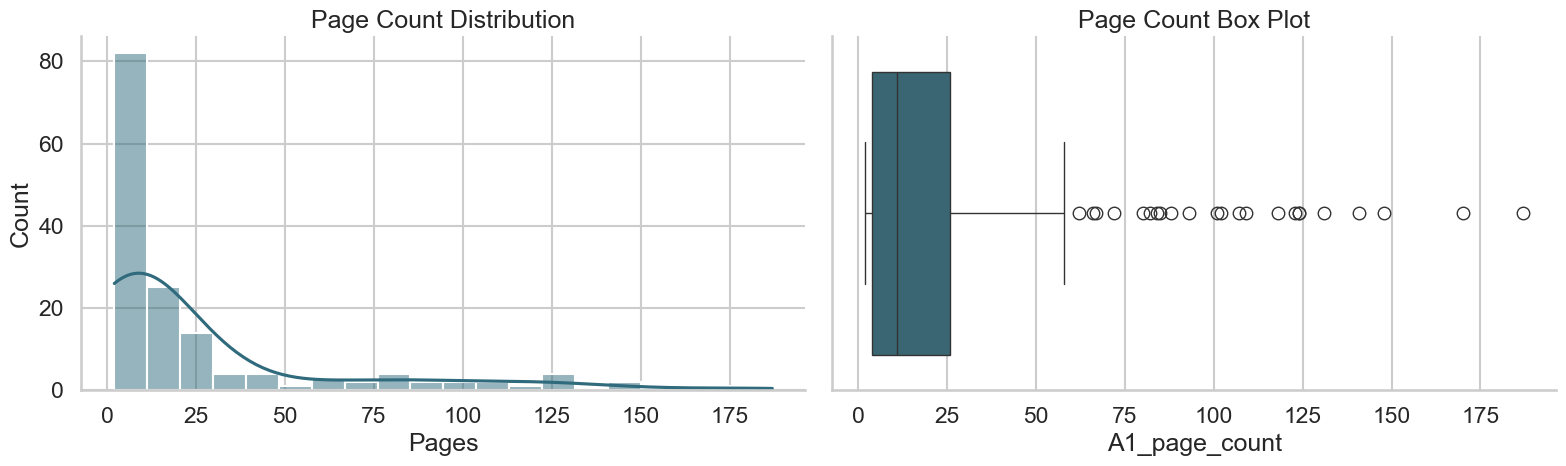

,count,mean,std,min,25%,50%,75%,max
Page Count,154.0,26.194805,37.785095,2.0,4.0,11.0,25.75,187.0


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(analysis_df['A1_page_count'], bins=20, kde=True, ax=axes[0], color='#2F6B7C')
axes[0].set_title('Page Count Distribution')
axes[0].set_xlabel('Pages')

sns.boxplot(x=analysis_df['A1_page_count'], ax=axes[1], color='#2F6B7C')
axes[1].set_title('Page Count Box Plot')
plt.tight_layout()
plt.show()

display(analysis_df['A1_page_count'].describe().to_frame('Page Count').T)

## B. Content Structure – Problem, Solutions, Implementation

Dimensions 2–4: Does the brief identify a problem, propose solutions, and discuss implementation?

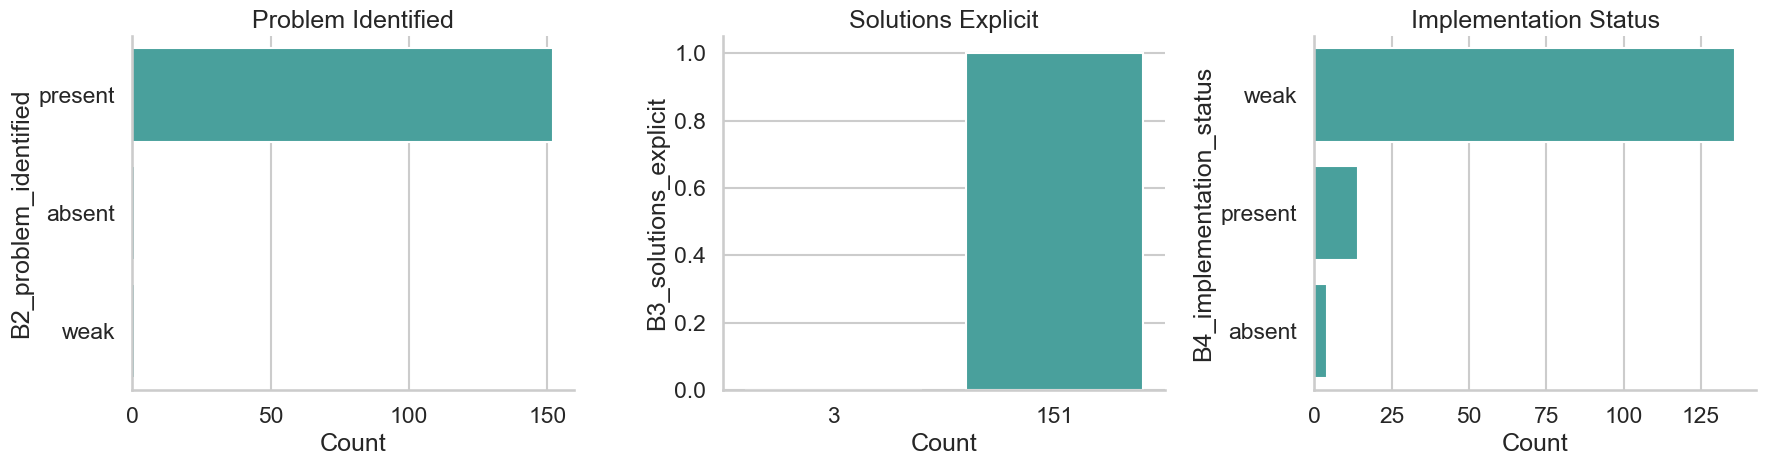

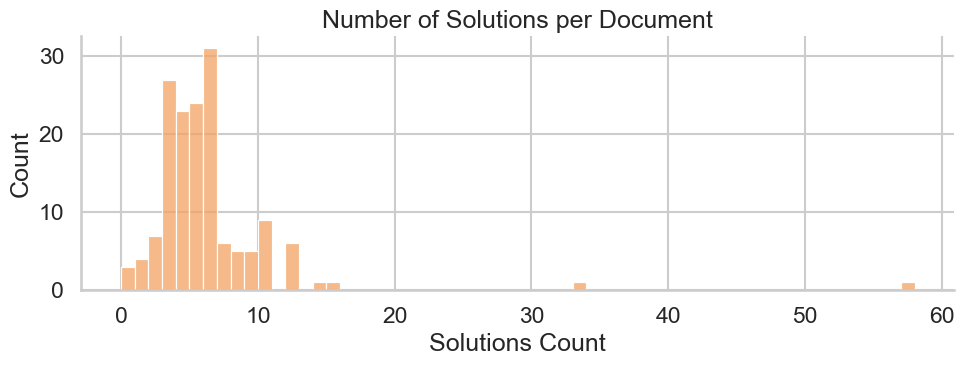

,Component,Count,Pct
0,Problem present,152,99%
1,Solutions explicit,151,98%
2,Implementation present,14,9%


In [29]:
content_cols = ['B2_problem_identified', 'B3_solutions_explicit', 'B4_implementation_status']
available = [c for c in content_cols if c in analysis_df.columns]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5))
    if len(available) == 1:
        axes = [axes]
    for ax, col in zip(axes, available):
        vc = analysis_df[col].value_counts()
        sns.barplot(x=vc.values, y=vc.index, ax=ax, color='#3AAFA9')
        ax.set_title(col.split('_', 1)[1].replace('_', ' ').title())
        ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()

    # Solutions count distribution
    if 'B3_solutions_count' in analysis_df.columns:
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.histplot(analysis_df['B3_solutions_count'], bins=range(0, analysis_df['B3_solutions_count'].max() + 2),
                     ax=ax, color='#F4A261')
        ax.set_title('Number of Solutions per Document')
        ax.set_xlabel('Solutions Count')
        plt.tight_layout()
        plt.show()

    # Summary table
    summary_b = pd.DataFrame({
        'Component': ['Problem present', 'Solutions explicit', 'Implementation present'],
        'Count': [
            (analysis_df.get('B2_problem_identified', pd.Series()) == 'present').sum(),
            (analysis_df.get('B3_solutions_explicit', pd.Series()) == True).sum(),
            (analysis_df.get('B4_implementation_status', pd.Series()) == 'present').sum(),
        ],
        'Pct': [
            f"{(analysis_df.get('B2_problem_identified', pd.Series()) == 'present').mean():.0%}",
            f"{(analysis_df.get('B3_solutions_explicit', pd.Series()) == True).mean():.0%}",
            f"{(analysis_df.get('B4_implementation_status', pd.Series()) == 'present').mean():.0%}",
        ]
    })
    display(summary_b)
else:
    print('Content-structure columns not available.')

## C. Bridging Role – Procedural Clarity, Responsibility, Outcomes

Dimensions 5–7: Does the brief tell readers *how* to act (procedural clarity), *who* should act (responsibility), and *what is expected* (anticipated outcomes)?

,Dimension,Present,Pct
0,C5 Procedural clarity,13,8%
1,C6 Responsibility,0,0%
2,C7 Anticipated outcomes,0,0%


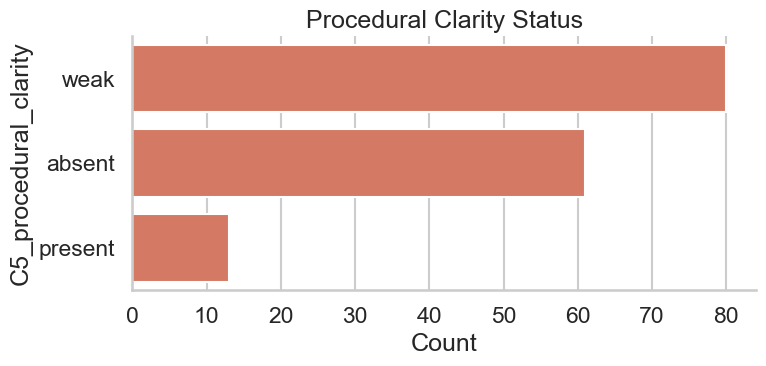

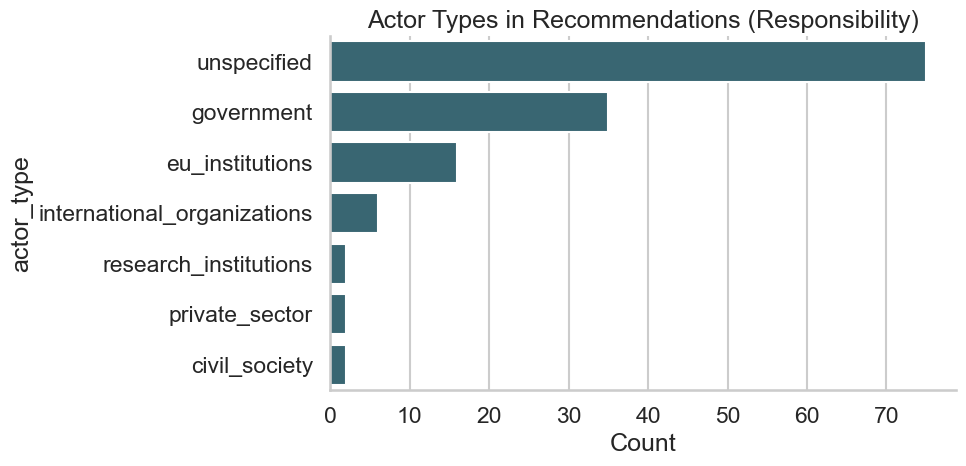

In [30]:
bridging_bools = {
    'C5 Procedural clarity': 'C5_procedural_clarity',
    'C6 Responsibility': 'C6_responsibility',
    'C7 Anticipated outcomes': 'C7_anticipated_outcomes',
}
bridging_data = []
for label, col in bridging_bools.items():
    if col not in analysis_df.columns:
        continue
    s = analysis_df[col]
    if s.dtype == bool:
        count = s.sum()
    else:
        count = (s == 'present').sum()
    bridging_data.append({'Dimension': label, 'Present': count,
                          'Pct': f'{count / len(analysis_df):.0%}'})

if bridging_data:
    display(pd.DataFrame(bridging_data))

    # Procedural clarity bar
    if 'C5_procedural_clarity' in analysis_df.columns:
        fig, ax = plt.subplots(figsize=(8, 4))
        vc = analysis_df['C5_procedural_clarity'].value_counts()
        sns.barplot(x=vc.values, y=vc.index, ax=ax, color='#E76F51')
        ax.set_title('Procedural Clarity Status')
        ax.set_xlabel('Count')
        plt.tight_layout()
        plt.show()

    # Actor types across recommendations (responsibility detail)
    if len(recommendations) and 'actor_type' in recommendations.columns:
        recs_with_actor = recommendations.dropna(subset=['actor_type'])
        if len(recs_with_actor):
            fig, ax = plt.subplots(figsize=(10, 5))
            order = recs_with_actor['actor_type'].value_counts().index
            sns.countplot(data=recs_with_actor, y='actor_type', order=order, ax=ax, color='#2F6B7C')
            ax.set_title('Actor Types in Recommendations (Responsibility)')
            ax.set_xlabel('Count')
            plt.tight_layout()
            plt.show()
else:
    print('Bridging-role columns not available.')

## D. Facilitating Role – Policy Options, Trade-offs, Impacts

Dimensions 8–10: Does the brief present policy alternatives, discuss trade-offs, and address potential impacts?

,Dimension,Present,Pct
0,D8 Impacts (proxy),10,6%
1,D9 Trade-offs,10,6%
2,D10 Policy options,16,10%


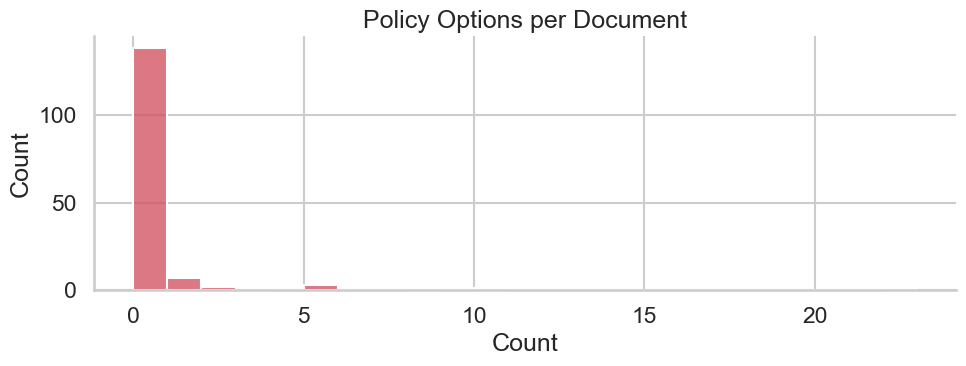

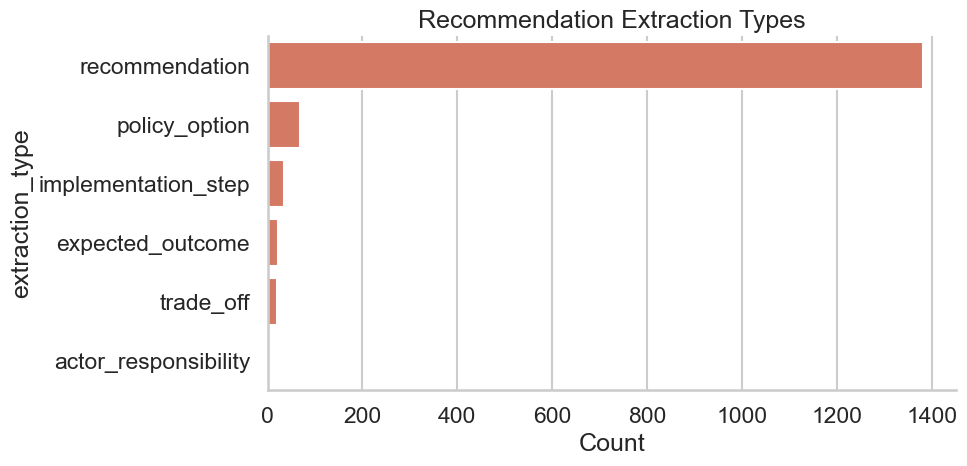

In [31]:
facil_bools = {
    'D8 Impacts (proxy)': 'D8_impacts_proxy',
    'D9 Trade-offs': 'D9_tradeoffs',
    'D10 Policy options': 'D10_policy_options',
}
facil_data = []
for label, col in facil_bools.items():
    if col not in analysis_df.columns:
        continue
    count = analysis_df[col].sum()
    facil_data.append({'Dimension': label, 'Present': int(count),
                       'Pct': f'{count / len(analysis_df):.0%}'})

if facil_data:
    display(pd.DataFrame(facil_data))

    # Policy options count distribution
    if 'D10_policy_options_count' in analysis_df.columns:
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.histplot(analysis_df['D10_policy_options_count'],
                     bins=range(0, max(analysis_df['D10_policy_options_count'].max() + 2, 3)),
                     ax=ax, color='#D1495B')
        ax.set_title('Policy Options per Document')
        ax.set_xlabel('Count')
        plt.tight_layout()
        plt.show()

    # Extraction type breakdown (recs)
    if len(recommendations):
        fig, ax = plt.subplots(figsize=(10, 5))
        ext = recommendations['extraction_type'].value_counts()
        sns.barplot(x=ext.values, y=ext.index, ax=ax, color='#E76F51')
        ax.set_title('Recommendation Extraction Types')
        ax.set_xlabel('Count')
        plt.tight_layout()
        plt.show()
else:
    print('Facilitating-role columns not available.')

## E. Accessibility – Voice, Sentence Length, Complexity, Reading Ease

Dimensions 11–14: Language indicators that affect whether readers can engage with the brief.

,count,mean,std,min,25%,50%,75%,max
E11 Passive voice share,154.0,0.237240,0.102351,0.000,0.167125,0.23795,0.298150,0.5000
E12 Avg sentence length,154.0,22.650909,4.779191,12.230,19.290000,22.52500,25.590000,45.7800
E13 Lexical diversity,154.0,0.361586,0.118194,0.096,0.281825,0.36630,0.428075,0.6263
E14 Flesch reading ease,154.0,20.602078,8.891327,-14.510,14.772500,20.24000,26.595000,44.3800
E14 Flesch-Kincaid grade,154.0,15.676948,1.839942,10.970,14.520000,15.69500,16.637500,24.6700


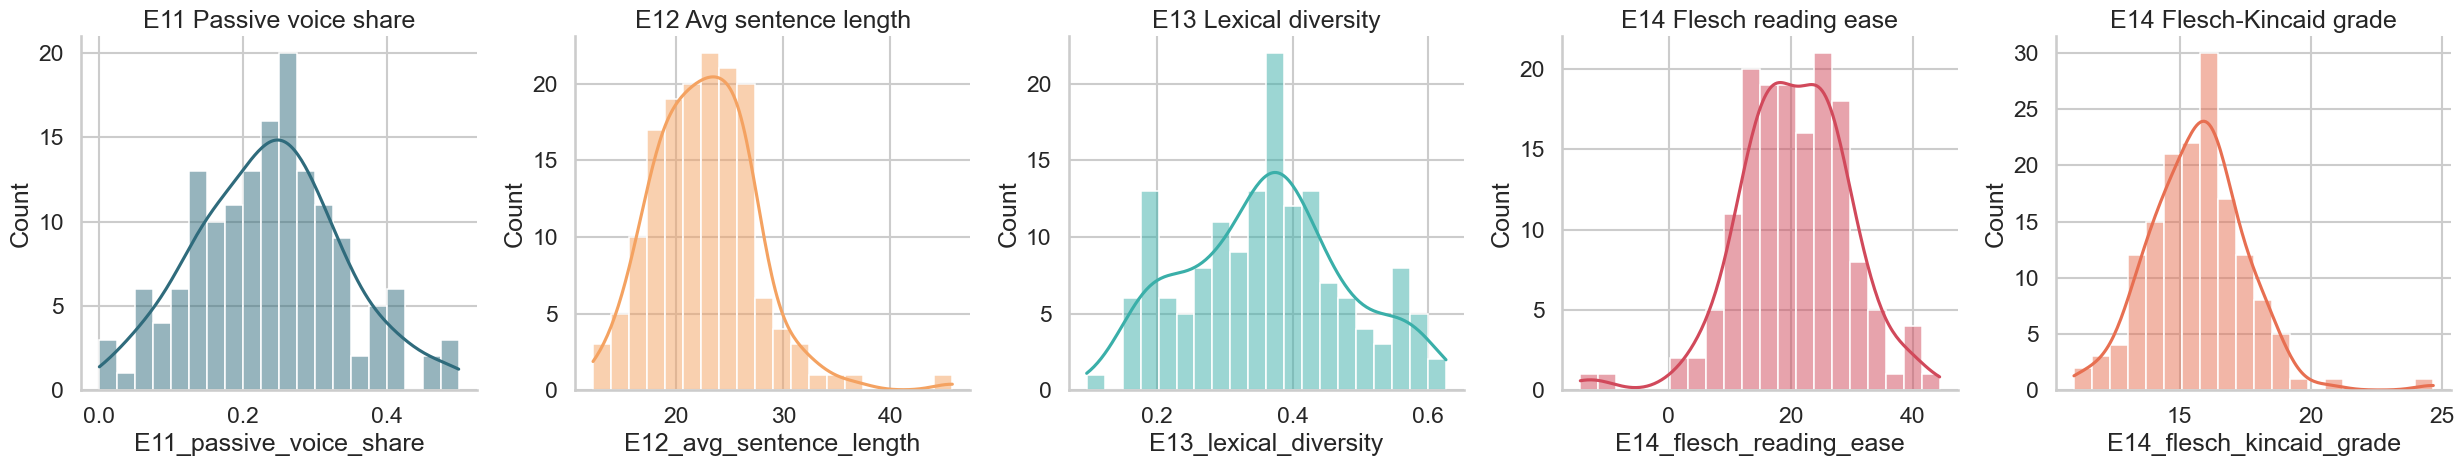

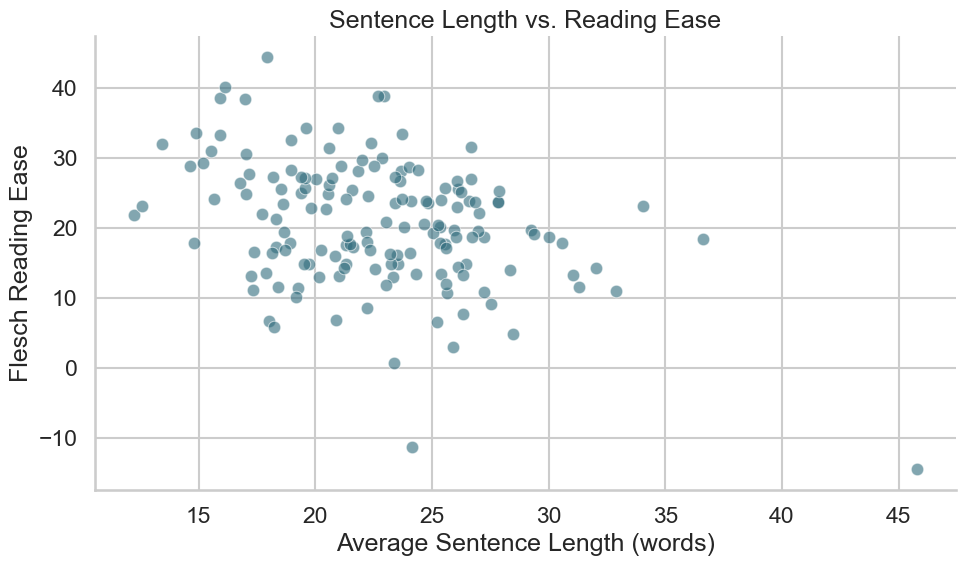

In [32]:
access_cols = [
    ('E11 Passive voice share', 'E11_passive_voice_share'),
    ('E12 Avg sentence length', 'E12_avg_sentence_length'),
    ('E13 Lexical diversity', 'E13_lexical_diversity'),
    ('E14 Flesch reading ease', 'E14_flesch_reading_ease'),
    ('E14 Flesch-Kincaid grade', 'E14_flesch_kincaid_grade'),
]
available_access = [(l, c) for l, c in access_cols if c in analysis_df.columns and analysis_df[c].notna().any()]

if available_access:
    # Summary statistics
    stats = pd.DataFrame({
        label: analysis_df[col].describe() for label, col in available_access
    }).T
    display(stats)

    n = len(available_access)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    colors = ['#2F6B7C', '#F4A261', '#3AAFA9', '#D1495B', '#E76F51']
    for ax, (label, col), c in zip(axes, available_access, colors):
        data = analysis_df[col].dropna()
        sns.histplot(data, bins=20, kde=True, ax=ax, color=c)
        ax.set_title(label)
    plt.tight_layout()
    plt.show()

    # Scatter: sentence length vs reading ease
    if 'E12_avg_sentence_length' in analysis_df.columns and 'E14_flesch_reading_ease' in analysis_df.columns:
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.scatterplot(data=analysis_df, x='E12_avg_sentence_length', y='E14_flesch_reading_ease',
                        alpha=0.6, color='#2F6B7C', ax=ax)
        ax.set_title('Sentence Length vs. Reading Ease')
        ax.set_xlabel('Average Sentence Length (words)')
        ax.set_ylabel('Flesch Reading Ease')
        plt.tight_layout()
        plt.show()
else:
    print('No accessibility columns available.')

## F. Narrative & Framing – Storytelling / Hooks

Dimension 15: Does the brief open with a narrative hook (statistic, anecdote, scenario, etc.)?

Documents with narrative hook: 152 / 154 (99%)


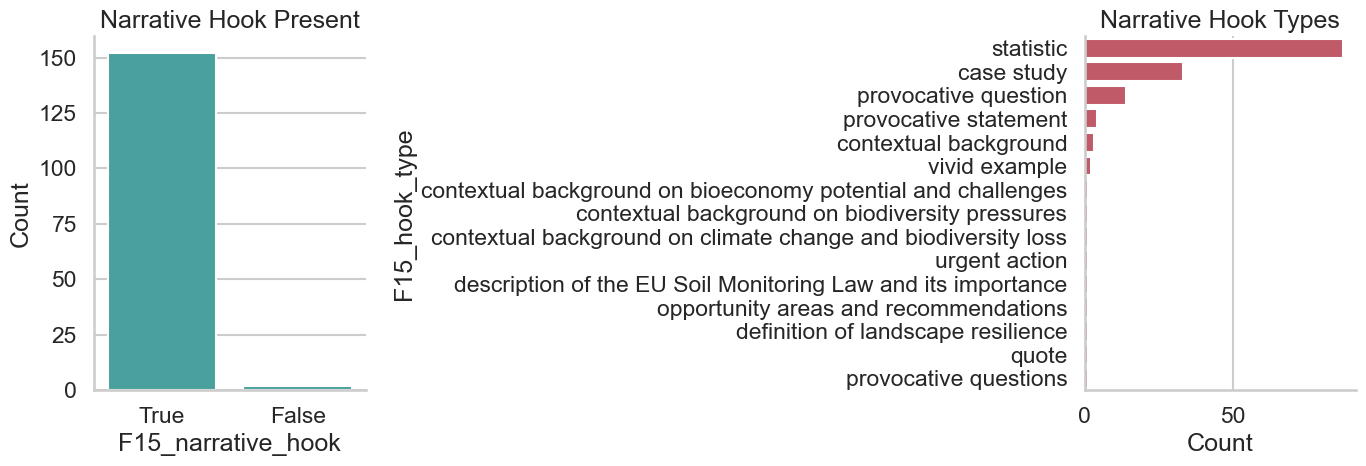

In [33]:
if 'F15_narrative_hook' in analysis_df.columns:
    hook_pct = analysis_df['F15_narrative_hook'].sum() / len(analysis_df)
    print(f'Documents with narrative hook: {analysis_df["F15_narrative_hook"].sum()} / {len(analysis_df)} ({hook_pct:.0%})')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Hook presence
    vc = analysis_df['F15_narrative_hook'].value_counts()
    sns.barplot(x=vc.index.astype(str), y=vc.values, ax=axes[0], color='#3AAFA9')
    axes[0].set_title('Narrative Hook Present')
    axes[0].set_ylabel('Count')

    # Hook types (where present)
    if 'F15_hook_type' in analysis_df.columns:
        hook_types = analysis_df.loc[analysis_df['F15_narrative_hook'] == True, 'F15_hook_type'].value_counts()
        if len(hook_types):
            sns.barplot(x=hook_types.values, y=hook_types.index, ax=axes[1], color='#D1495B')
            axes[1].set_title('Narrative Hook Types')
            axes[1].set_xlabel('Count')
        else:
            axes[1].set_title('Hook Types (none)')
    plt.tight_layout()
    plt.show()
else:
    print('Narrative hook column not available.')

## G. Transparency – Funding, Study Link, Contact

Dimensions 16–18: Does the brief disclose funding, link to the underlying study, and provide author contact details?

,Dimension,Present,Pct
0,G16 Funding disclosed,107,69%
1,G18 Contact info,128,83%


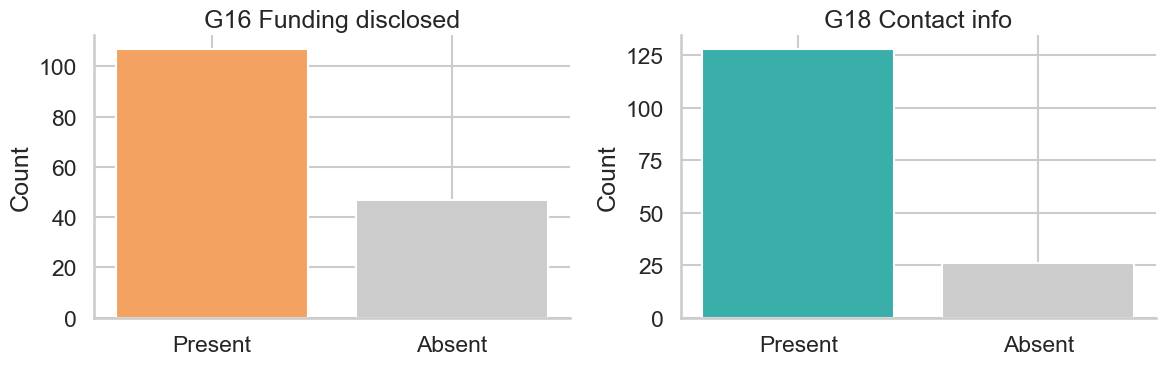

In [34]:
transp_data = []
for label, col in [('G16 Funding disclosed', 'G16_funding'), ('G18 Contact info', 'G18_contact_info')]:
    if col not in analysis_df.columns:
        continue
    s = analysis_df[col]
    if s.dtype == bool:
        count = int(s.sum())
    elif s.notna().any():
        count = int(s.astype(bool).sum())
    else:
        count = 0
    transp_data.append({'Dimension': label, 'Present': count,
                        'Pct': f'{count / len(analysis_df):.0%}'})

if transp_data:
    display(pd.DataFrame(transp_data))

    fig, axes = plt.subplots(1, len(transp_data), figsize=(6 * len(transp_data), 4))
    if len(transp_data) == 1:
        axes = [axes]
    colors = ['#F4A261', '#3AAFA9']
    for ax, row, c in zip(axes, transp_data, colors):
        vals = [row['Present'], len(analysis_df) - row['Present']]
        ax.bar(['Present', 'Absent'], vals, color=[c, '#cccccc'])
        ax.set_title(row['Dimension'])
        ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('Transparency columns not available.')

## H. Theory-Informed Policy-Instrument Frames

Dimensions 19–24: Prevalence of the five coded frame types and whether the brief exhibits a policy mix (≥ 2 frames).

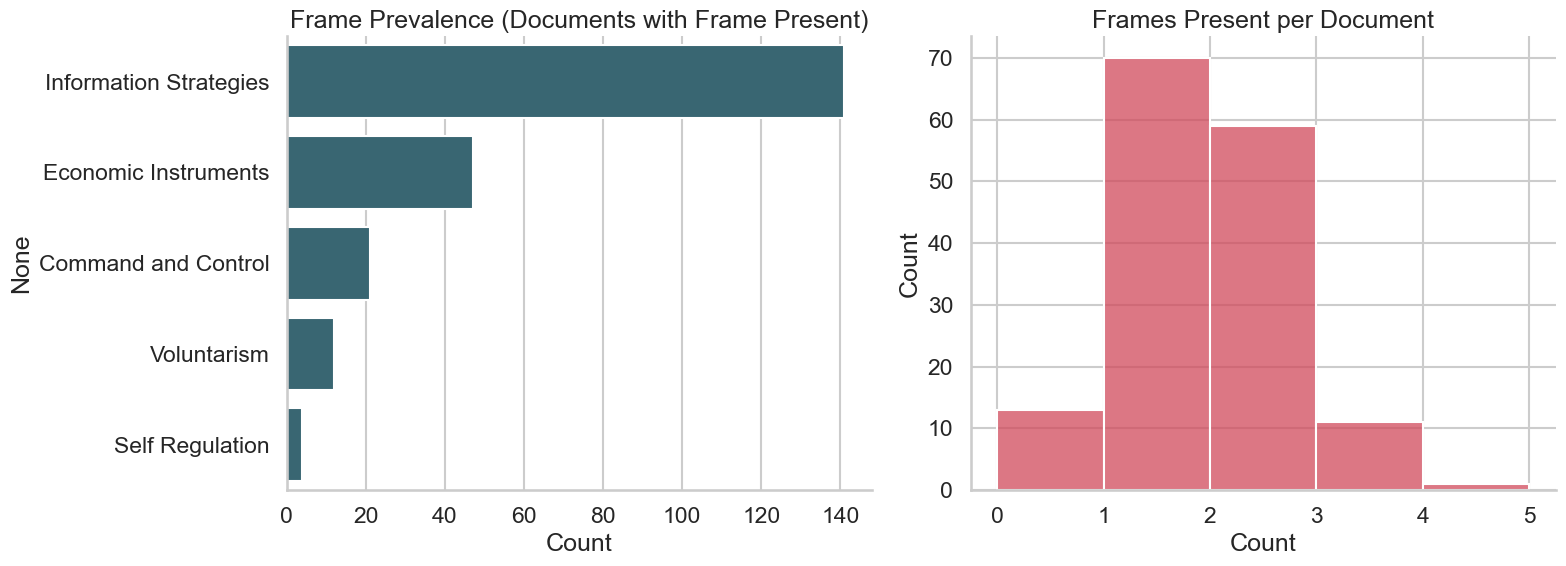

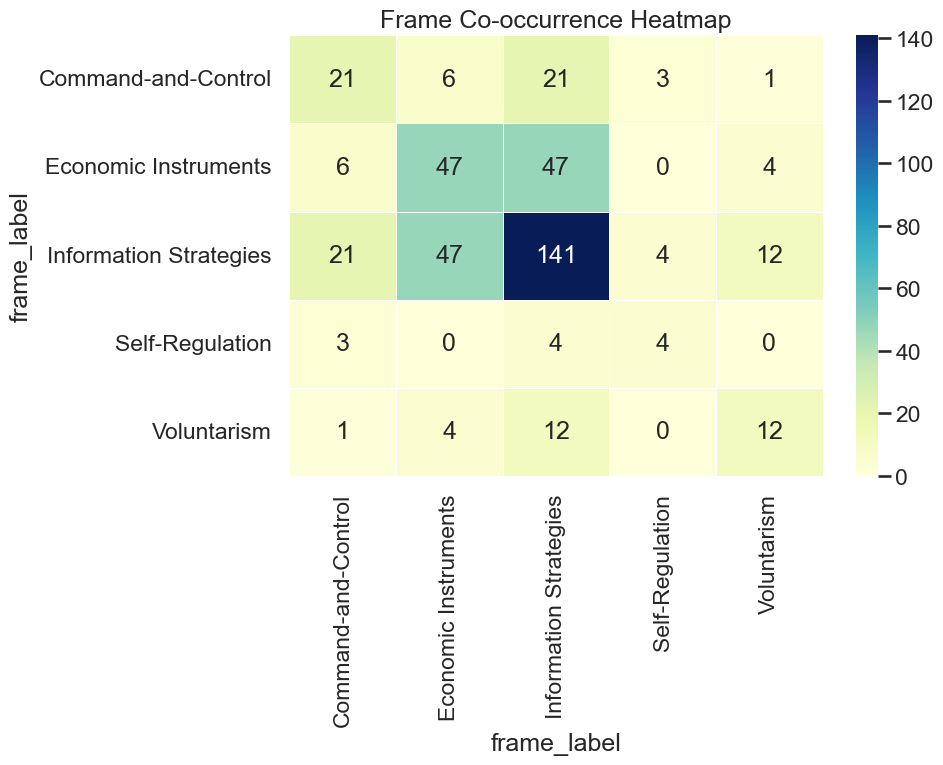

Policy mix (≥2 frames): 71 / 154 (46%)


In [35]:
h_cols = [c for c in analysis_df.columns if c.startswith('H_') and c != 'H_frames_present_count' and c != 'H24_policy_mix']

if h_cols:
    # Frame prevalence
    frame_prev = analysis_df[h_cols].sum().sort_values(ascending=False)
    frame_prev.index = [c.replace('H_', '').replace('_', ' ') for c in frame_prev.index]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(x=frame_prev.values, y=frame_prev.index, ax=axes[0], color='#2F6B7C')
    axes[0].set_title('Frame Prevalence (Documents with Frame Present)')
    axes[0].set_xlabel('Count')

    # Frames per document
    if 'H_frames_present_count' in analysis_df.columns:
        sns.histplot(analysis_df['H_frames_present_count'],
                     bins=range(0, analysis_df['H_frames_present_count'].max() + 2),
                     ax=axes[1], color='#D1495B')
        axes[1].set_title('Frames Present per Document')
        axes[1].set_xlabel('Count')
    plt.tight_layout()
    plt.show()

    # Co-occurrence heatmap
    if len(frames):
        present = frames[frames['decision'] == 'present']
        pm = present.assign(v=1).pivot_table(index='doc_id', columns='frame_label', values='v', fill_value=0)
        cooc = pm.T.dot(pm)
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(cooc, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5, ax=ax)
        ax.set_title('Frame Co-occurrence Heatmap')
        plt.tight_layout()
        plt.show()

    # Policy mix
    if 'H24_policy_mix' in analysis_df.columns:
        mix_count = analysis_df['H24_policy_mix'].sum()
        print(f'Policy mix (≥2 frames): {int(mix_count)} / {len(analysis_df)} ({mix_count / len(analysis_df):.0%})')
else:
    print('Frame columns not available.')

## QA Appendix: Raw Extraction Distributions & Correlations

Low-level diagnostics on data quality, missingness, and inter-variable relationships.

,dataset,rows,columns,missing_cells
0,documents,154,33,774
1,frames,770,9,926
2,recommendations,1534,15,12409
3,structural_core,154,13,3


**Top missing columns in documents.csv:**

,missing
warnings,154
fm_emails,124
title,119
author,107
fm_urls,60
fm_affiliation_types,57
fm_affiliations,57
fm_authors,49
funding_statements_raw,47
doc_id,0


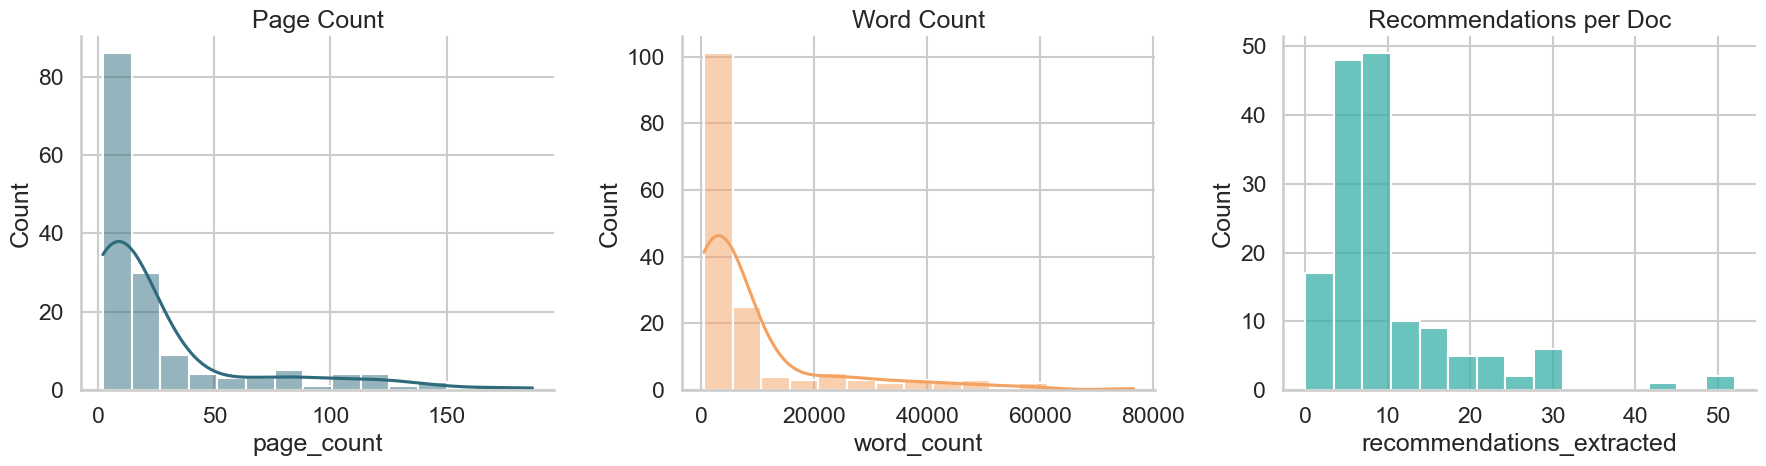

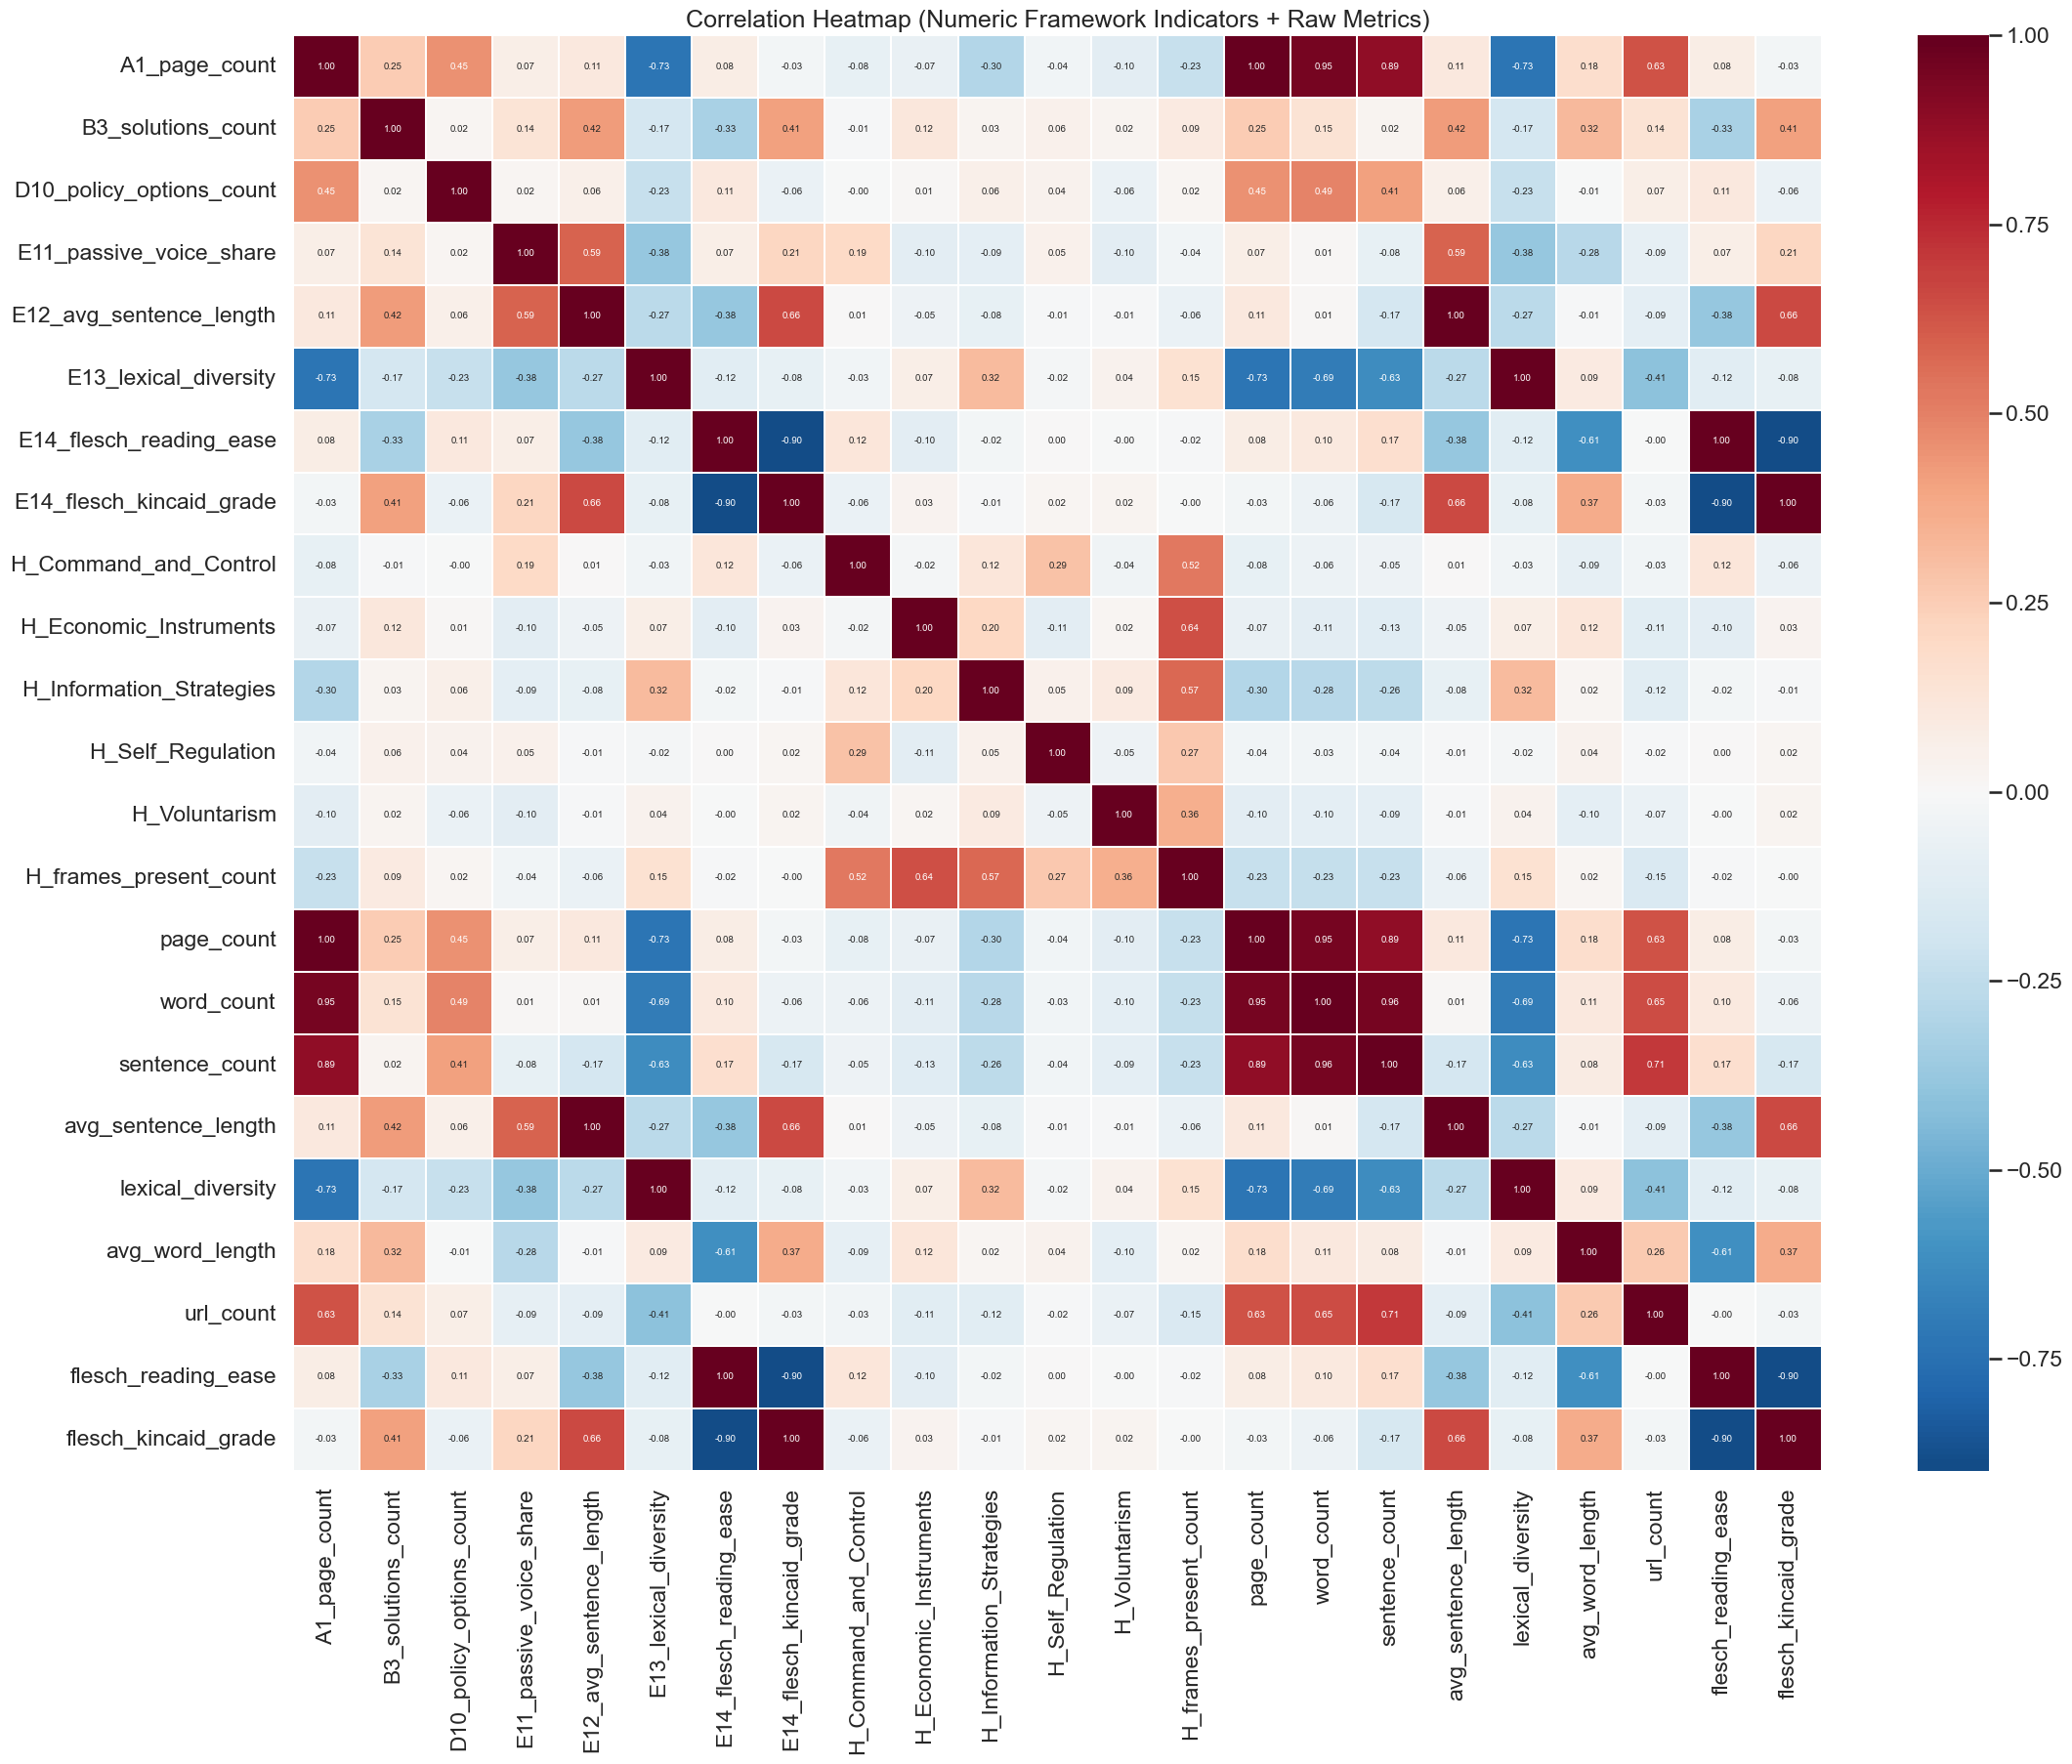

**Top 10 documents by recommendation count:**

,doc_id,page_count,word_count,recommendations_extracted
135,silvanus_2,118,57508,52
46,desira_1,170,76556,52
73,eklipse_4,107,50626,45
71,eklipse_2,124,46258,30
126,resonate_3,82,26603,28
85,genres_bridge_2,80,21003,28
47,desira_2,101,29712,28
116,pegasus,43,18778,28
134,silvanus_1,148,58429,28
96,impetus,123,42515,27


In [36]:
# ── Dataset-level summary ────────────────────────────────────────────────
qa_summary = pd.DataFrame({
    'dataset': ['documents', 'frames', 'recommendations', 'structural_core'],
    'rows': [len(documents), len(frames), len(recommendations), len(structural_core)],
    'columns': [documents.shape[1], frames.shape[1], recommendations.shape[1], structural_core.shape[1]],
    'missing_cells': [
        documents.isna().sum().sum(), frames.isna().sum().sum(),
        recommendations.isna().sum().sum(), structural_core.isna().sum().sum()
    ],
})
display(qa_summary)

# ── Missingness in documents ────────────────────────────────────────────
display(Markdown('**Top missing columns in documents.csv:**'))
display(documents.isna().sum().sort_values(ascending=False).head(10).rename('missing').to_frame())

# ── Key distributions ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(documents['page_count'], bins=15, kde=True, ax=axes[0], color='#2F6B7C')
axes[0].set_title('Page Count')
sns.histplot(documents['word_count'], bins=15, kde=True, ax=axes[1], color='#F4A261')
axes[1].set_title('Word Count')
if _has_col(documents, 'recommendations_extracted'):
    sns.histplot(documents['recommendations_extracted'], bins=15, ax=axes[2], color='#3AAFA9')
    axes[2].set_title('Recommendations per Doc')
plt.tight_layout()
plt.show()

# ── Correlation heatmap ─────────────────────────────────────────────────
numeric_cols = [c for c in [
    'page_count', 'word_count', 'sentence_count', 'avg_sentence_length',
    'lexical_diversity', 'avg_word_length', 'url_count',
    'flesch_reading_ease', 'flesch_kincaid_grade',
] if c in documents.columns]
# Add framework derived numerics
for c in analysis_df.select_dtypes(include='number').columns:
    if c not in numeric_cols and c != 'doc_id':
        numeric_cols.append(c)

corr_df = analysis_df.merge(documents[['doc_id'] + [c for c in numeric_cols if c in documents.columns]],
                            on='doc_id', how='left', suffixes=('', '_dup'))
# Drop dups
corr_df = corr_df[[c for c in corr_df.columns if not c.endswith('_dup')]]
num = corr_df.select_dtypes(include='number').drop(columns=['doc_id'], errors='ignore')
if num.shape[1] > 2:
    corr = num.corr()
    fig, ax = plt.subplots(figsize=(max(12, num.shape[1]), max(10, num.shape[1] * 0.8)))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.3, ax=ax,
                annot_kws={'size': 7})
    ax.set_title('Correlation Heatmap (Numeric Framework Indicators + Raw Metrics)')
    plt.tight_layout()
    plt.show()

# ── Documents with extreme values ──────────────────────────────────────
display(Markdown('**Top 10 documents by recommendation count:**'))
display(
    documents[['doc_id', 'page_count', 'word_count', 'recommendations_extracted']]
    .sort_values('recommendations_extracted', ascending=False)
    .head(10)
)